# Credit Risk Classification: Lending Club Loan Dataset

This notebook builds a binary credit default classifier on Lending Club consumer loan data — predicting whether a borrower will default before their loan resolves.

One deliberate constraint shapes the entire analysis: 

>Lending Club's proprietary risk grades (`grade`, `sub_grade`) are excluded from the feature set. These features are powerful predictors, but a lender building their own risk model wouldn't have access to a competitor's internal scoring. Removing them forces the model to find signal in raw borrower fundamentals — which turns out to be a more interesting problem.

The dataset covers 2017–2019 loan vintages — post-crisis, pre-COVID, representative of normal credit conditions. Only resolved loans (fully paid or charged off) are used, ensuring clean ground truth labels.

**What this notebook covers:**
- A reusable preprocessing pipeline built for all three notebooks in this series
- Exploratory analysis of borrower risk factors
- Feature engineering to capture affordability, utilization, and credit history
- Baseline comparison across three model architectures
- Hyperparameter tuning delivering AUC 0.7366 without proprietary grade features

---

## Setup & Data Loading

### Imports

In [1]:
# General Utilities
from pathlib import Path
import joblib
import json

# Sci-Kit Learn & XGBoost Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Local Package Imports (fintech_ml)
from banking_ml.utils import (
    load_data, 
    inspect_dataframe, 
    save_data_summary_tables, 
    clean_raw_data, 
    assess_features,
    filter_by_vintage,
    report_skewness,
)

from banking_ml.preprocessing import (
    drop_high_missingness,
    inspect_target,
    encode_binary_target,
    drop_leakage_columns,
    split_data,
    select_core_features,
)

from banking_ml.feature_engineering import (
    engineer_features,
)

from banking_ml.visualization import (
    plot_class_distribution,
    plot_numeric_distributions,
    plot_default_rate_by_category,
    plot_correlation_heatmap,
    plot_missingness,
    plot_feature_target_correlation,
    plot_roc_curves,
)

from banking_ml.pipelines import (
    build_pipeline,
)

from banking_ml.models import (
    tune_model, 
    get_xgb_param_grid, 
    display_best_params,
)

from banking_ml.evaluation import (
    evaluate_classifier,
    compare_classifiers,
)

from banking_ml.explainability import (
    get_shap_values,
    plot_shap_summary,
    plot_shap_beeswarm,
)

### Paths

In [2]:
# Project Root
PROJECT_ROOT = Path.cwd().parent.resolve()

# Data Path
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Artifacts Base Directory
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# Classification Artifacts
CLASSIFICATION_DIR = ARTIFACTS_DIR / "classification"

# EDA
EDA_FIGURES_DIR = CLASSIFICATION_DIR / "eda" / "figures"
EDA_TABLES_DIR = CLASSIFICATION_DIR / "eda" / "tables"

# Models
MODELS_DIR = CLASSIFICATION_DIR / "models"
FIGURES_DIR = MODELS_DIR / "figures"
TABLES_DIR = MODELS_DIR / "tables"
PARAMS_DIR = MODELS_DIR / "params"

# Create all directories if missing
for d in [
    EDA_FIGURES_DIR,
    EDA_TABLES_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    PARAMS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

### Load Dataset


Working with Lending Club loan data spanning 2007–2020, the analysis focuses on **2017–2019 vintages** — the most recent fully resolved loans before COVID distortions hit. Loans from this window have had enough time to reach a clear outcome, and the credit environment is representative of modern lending conditions.

In [3]:
DATA_LOAD_PATH = DATA_DIR / "Loan_status_2007-2020Q3.gzip"

df = load_data(DATA_LOAD_PATH)
df = filter_by_vintage(df, start_year=2017, end_year=2019)

Vintage filter: 2017 – 2019
Filtered dataset shape: (1456928, 141)


### Clean Raw Data

In [4]:
df = clean_raw_data(df)
df.head()

,Unnamed: 0,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,debt_settlement_flag
230717,0,120122535,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230718,1,119374887,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,...,Apr-2020,Jun-2020,Apr-2020,2.0,0.0,ACTIVE,123.08000,6189.66,1062.71,N
230719,2,119321612,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230720,3,120122034,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
230721,4,118659541,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,...,Feb-2020,Apr-2020,Feb-2020,3.0,21.0,DELINQUENT,177.96231,10197.78,59.68,N


---

## Initial Data Inspection

### Dataset Overview

In [5]:
inspect_dataframe(df)

DATAFRAME SUMMARY

Shape: 1,456,928 rows x 141 columns

Dtype breakdown:
float64    108
str         32
int64        1

Duplicate rows: 0

Columns with missing values: 52 of 141
hardship_loan_status                          91.77
deferral_term                                 91.76
hardship_status                               91.76
hardship_type                                 91.76
hardship_dpd                                  91.76
hardship_length                               91.76
payment_plan_start_date                       91.76
hardship_end_date                             91.76
hardship_start_date                           91.76
hardship_reason                               91.76
orig_projected_additional_accrued_interest    89.67
hardship_last_payment_amount                  89.59
hardship_amount                               89.59
hardship_payoff_balance_amount                89.59
verification_status_joint                     88.35
sec_app_revol_util                         

### Drop High Missingness


The raw dataset arrives with 141 columns, many sparsely populated — hardship programs, settlement data, joint application fields. A first missingness pass at **50%** removes these structurally empty columns without touching any features with real signal.

In [6]:
df_clean = drop_high_missingness(df)

Dropping 34 columns above 50% missing threshold:
  mths_since_last_delinq: 54.4%
  mths_since_last_record: 86.7%
  mths_since_last_major_derog: 76.2%
  annual_inc_joint: 87.4%
  dti_joint: 87.4%
  verification_status_joint: 88.3%
  mths_since_recent_bc_dlq: 79.2%
  mths_since_recent_revol_delinq: 69.7%
  revol_bal_joint: 87.7%
  sec_app_fico_range_low: 87.7%
  sec_app_fico_range_high: 87.7%
  sec_app_earliest_cr_line: 87.7%
  sec_app_inq_last_6mths: 87.7%
  sec_app_mort_acc: 87.7%
  sec_app_open_acc: 87.7%
  sec_app_revol_util: 87.9%
  sec_app_open_act_il: 87.7%
  sec_app_num_rev_accts: 87.7%
  sec_app_chargeoff_within_12_mths: 87.7%
  sec_app_collections_12_mths_ex_med: 87.7%
  hardship_type: 91.8%
  hardship_reason: 91.8%
  hardship_status: 91.8%
  deferral_term: 91.8%
  hardship_amount: 89.6%
  hardship_start_date: 91.8%
  hardship_end_date: 91.8%
  payment_plan_start_date: 91.8%
  hardship_length: 91.8%
  hardship_dpd: 91.8%
  hardship_loan_status: 91.8%
  orig_projected_additional

---

## Target Variable Definition

### Target Variable Distribution

In [7]:
inspect_target(df_clean, "loan_status")

Target column: 'loan_status'
Unique values: 7

                     count    pct
loan_status                      
Current             844283  57.95
Fully Paid          459911  31.57
Charged Off         126702   8.70
Late (31-120 days)   14758   1.01
In Grace Period       8582   0.59
Late (16-30 days)     2354   0.16
Default                338   0.02


### Encode Binary Target


Only resolved loans have a known outcome. Current loans, late loans, and loans in grace period are excluded — keeping them would introduce noise since their final status is unknown. This reduces the dataset but produces clean, unambiguous labels. The resulting class split is roughly 80/20 non-default to default.

In [8]:
POSITIVE_CLASSES = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

NEGATIVE_CLASSES = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid"
]

df_clean = encode_binary_target(df_clean, "loan_status", POSITIVE_CLASSES, NEGATIVE_CLASSES)

Retained rows: 586,951
Default (1): 127,040 (21.6%)
Non-default (0): 459,911 (78.4%)


---

## Post-Encoding Inspection

### Inspect Dataframe

In [9]:
inspect_dataframe(df_clean)

DATAFRAME SUMMARY

Shape: 586,951 rows x 107 columns

Dtype breakdown:
float64    83
str        22
int64       2

Duplicate rows: 0

Columns with missing values: 18 of 107
next_pymnt_d             99.94
il_util                  14.54
mths_since_recent_inq     9.94
emp_title                 9.12
emp_length                7.87
num_tl_120dpd_2m          3.77
mths_since_rcnt_il        2.95
mo_sin_old_il_acct        2.95
bc_util                   1.45
percent_bc_gt_75          1.40
bc_open_to_buy            1.40
hardship_flag             1.38
mths_since_recent_bc      1.32
last_pymnt_d              0.36
dti                       0.18
revol_util                0.12
all_util                  0.02
avg_cur_bal               0.01


### Drop High Missingness


A second missingness pass at **40%** runs after target encoding. Filtering to resolved loans reveals additional missingness that wasn't visible in the full dataset — some feature blocks are sparsely populated specifically among resolved loans. Two passes avoids dropping useful features too aggressively upfront.

In [10]:
df_clean = drop_high_missingness(df_clean, threshold=0.4)

Dropping 1 columns above 40% missing threshold:
  next_pymnt_d: 99.9%


### Drop Data Leakage Features


Post-origination columns — payment history, recovery amounts, last payment date — are **explicitly removed**. These features are only observable after a loan outcome is known. A production model would never have access to them at scoring time, so including them would be misleading.

In [11]:
df_clean = drop_leakage_columns(df_clean)

Dropping 17 leakage columns
Dropping 7 administrative columns
Total dropped: 24
Remaining columns: 82


### Raw Data Summary

In [12]:
save_data_summary_tables(df_clean, "loan_status", EDA_TABLES_DIR / "raw")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/raw/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/raw/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/raw/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/raw/categorical_counts.csv


---

## Exploratory Data Analysis


Before building any models, it's worth understanding what the data actually looks like — which features correlate with default, where the class imbalance sits, and whether the distributions suggest any preprocessing needs. The EDA here is deliberately focused on features that will actually be used in modeling.

### Class Distribution


The dataset is imbalanced at roughly 80/20 non-default to default — typical for consumer credit. This imbalance is handled through balanced class weighting during training rather than resampling, which preserves the natural data distribution while preventing the model from simply predicting non-default for everything.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/01_class_distribution.png


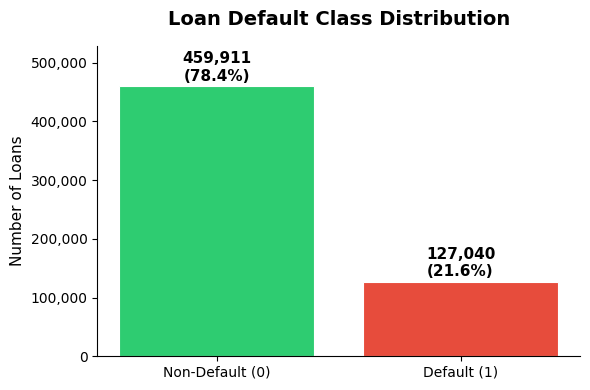

In [13]:
plot_class_distribution(
    df_clean,
    target_col="loan_status",
    save_path=EDA_FIGURES_DIR / "01_class_distribution.png"
)

### Plot Numeric Distributions


Eight features are selected for distribution analysis — the core affordability and credit behavior metrics most correlated with default. Displaying all numeric features would obscure the signal; these eight tell the clearest story about borrower risk.

Higher interest rates, debt-to-income ratios, and revolving balances skew toward defaulted loans — confirming these as meaningful risk signals. Annual income shows the opposite pattern, with non-defaulting borrowers generally earning more. These distributions motivate several of the engineered features built in the preprocessing section.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/02_numeric_distributions.png


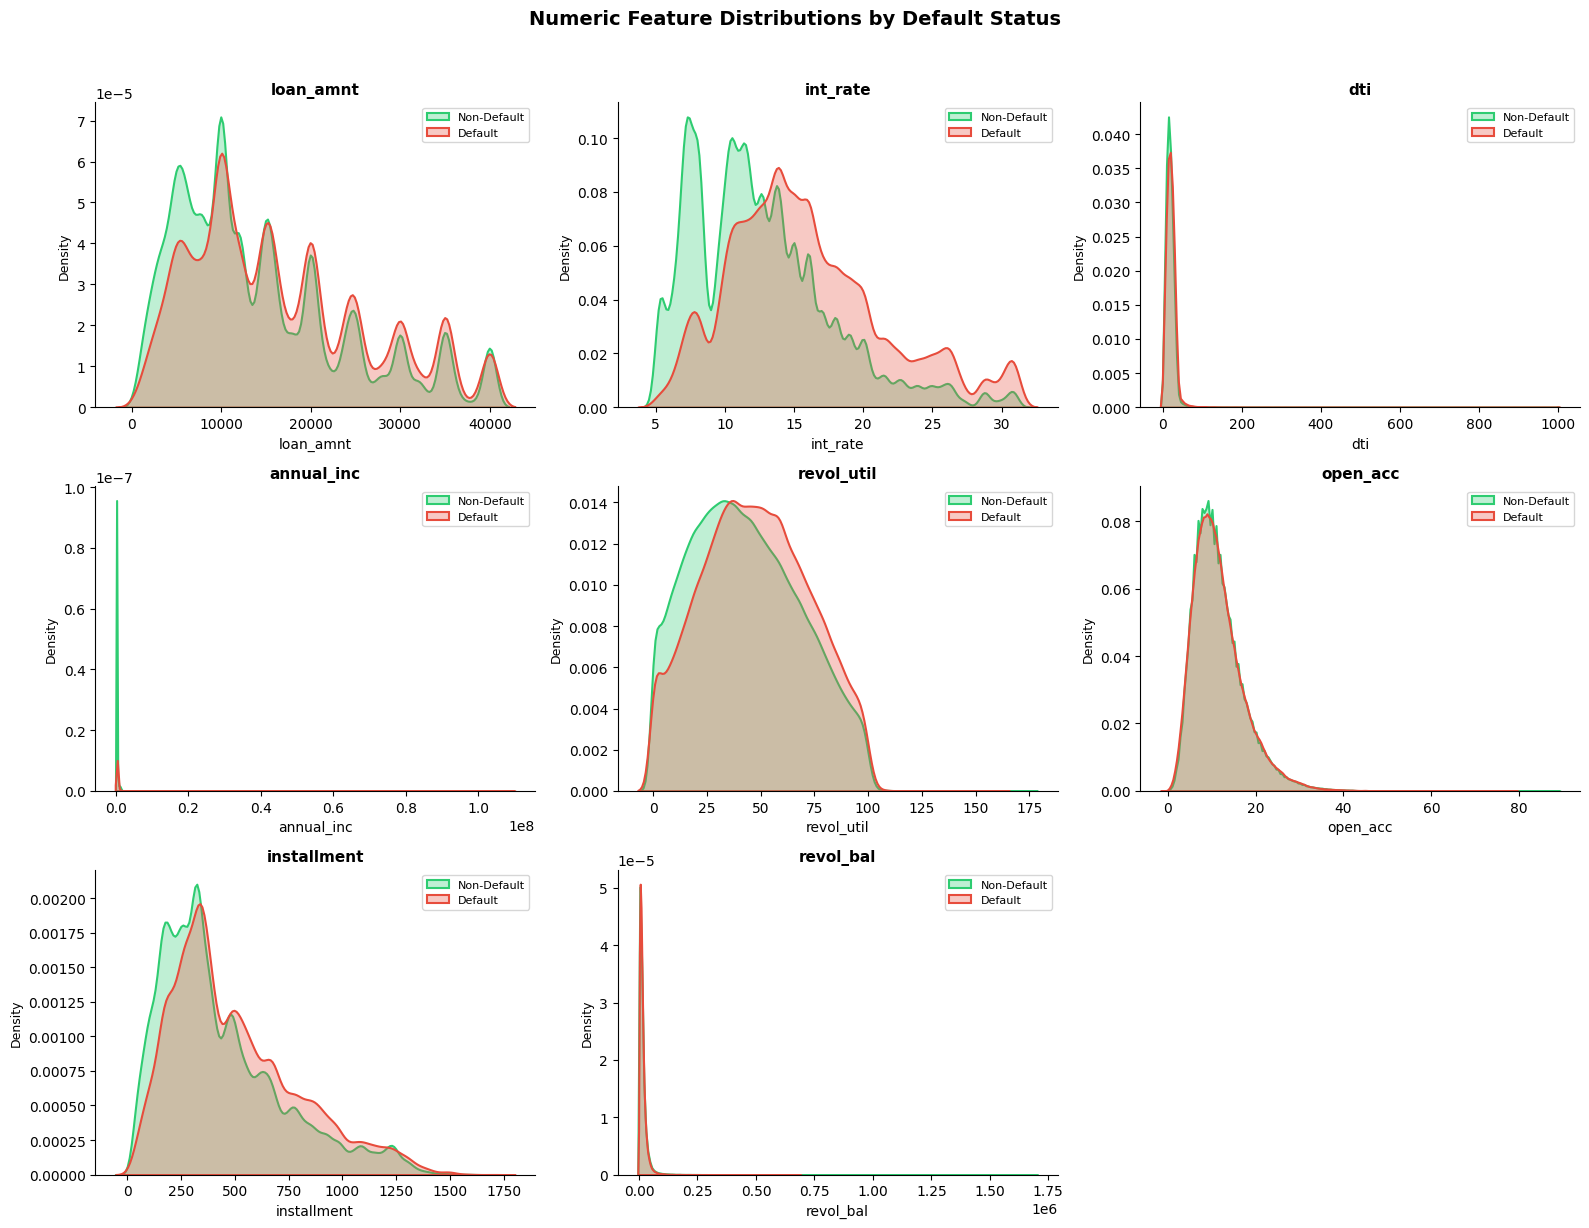

In [14]:
NUMERIC_COLS = [
    "loan_amnt", "int_rate", "dti", "annual_inc",
    "revol_util", "open_acc", "installment", "revol_bal"
]

plot_numeric_distributions(
    df_clean,
    numeric_cols=NUMERIC_COLS,
    target_col="loan_status",
    save_path=EDA_FIGURES_DIR / "02_numeric_distributions.png"
)

### Skewness Assessment


Several features in this dataset are heavily right-skewed — income, balance, and collection features in particular. While tree-based models are invariant to monotonic transformations and don't require skewness correction, understanding the distribution of raw features is useful context for interpreting EDA visualizations and imputation behavior.

In [15]:
skewed = report_skewness(df_clean, "loan_status")

Columns with skewness > 1.0: 58
Columns with skewness > 2.0: 35
Columns with skewness > 5.0: 17

Full list above 1.0:
tot_coll_amt                  517.834117
annual_inc                    433.001365
delinq_amnt                   158.458104
num_tl_120dpd_2m               57.131455
tax_liens                      36.842708
dti                            27.854637
num_tl_30dpd                   27.630690
acc_now_delinq                 23.339463
max_bal_bc                     21.633777
chargeoff_within_12_mths       19.836695
num_tl_90g_dpd_24m             16.034687
pub_rec                        11.066510
revol_bal                      10.885979
collections_12_mths_ex_med     10.442043
delinq_2yrs                     6.516227
total_rev_hi_lim                5.960851
num_accts_ever_120_pd           5.681856
mo_sin_rcnt_tl                  4.875041
total_bal_ex_mort               4.097633
total_bal_il                    3.842793
mths_since_recent_bc            3.826826
mths_since_rcnt_il   

### Default Rate by Category


Term is the strongest categorical predictor — 60-month loans carry meaningfully higher rates than 36-month loans, reflecting the additional duration risk. Purpose shows clear variation, with small business and moving loans at the higher end and major purchase and car loans at the lower end. Home ownership shows modest but consistent differences.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/03_default_rate_by_category.png


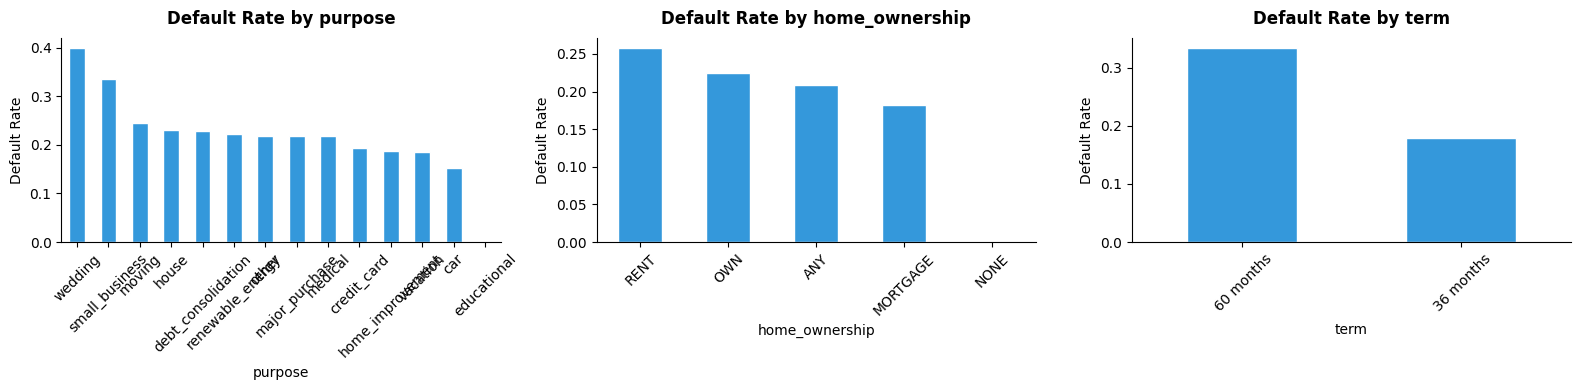

In [16]:
CAT_COLS = ["purpose", "home_ownership", "term"]

plot_default_rate_by_category(
    df_clean,
    cat_cols=CAT_COLS,
    target_col="loan_status",
    save_path=EDA_FIGURES_DIR / "03_default_rate_by_category.png"
)

### Correlation Heatmap


Interest rate dominates the correlation matrix — largely because it encodes Lending Club's own risk assessment. Features like `dti`, `revol_util`, and `inq_last_6mths` show the expected positive correlation with default. On the protective side, higher credit limits, mortgage accounts, and time since last inquiry all correlate with lower default rates.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/04_correlation_heatmap.png


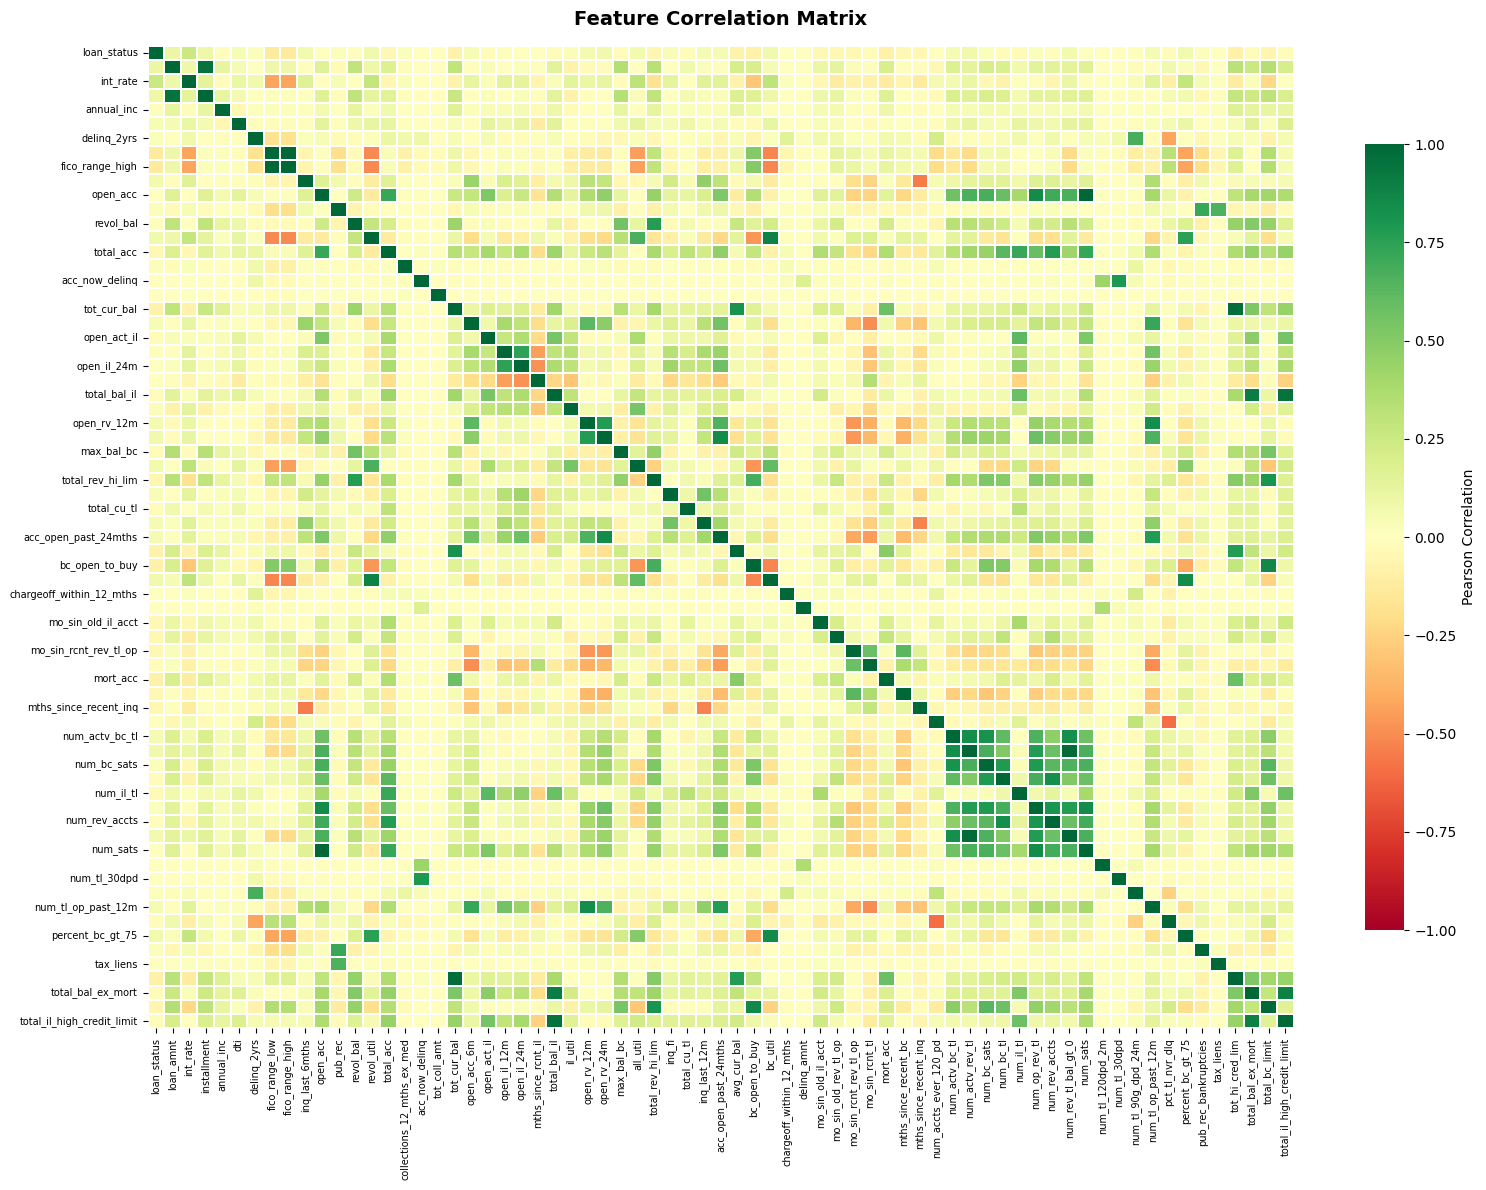

In [17]:
plot_correlation_heatmap(
    df_clean,
    target_col="loan_status",
    save_path=EDA_FIGURES_DIR / "04_correlation_heatmap.png"
)

### Missingness


After two missingness passes most remaining features have low null rates. The exceptions are features like `mort_acc` and `bc_open_to_buy` which have moderate missingness — handled downstream by median imputation in the preprocessing pipeline.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/05_missingness.png


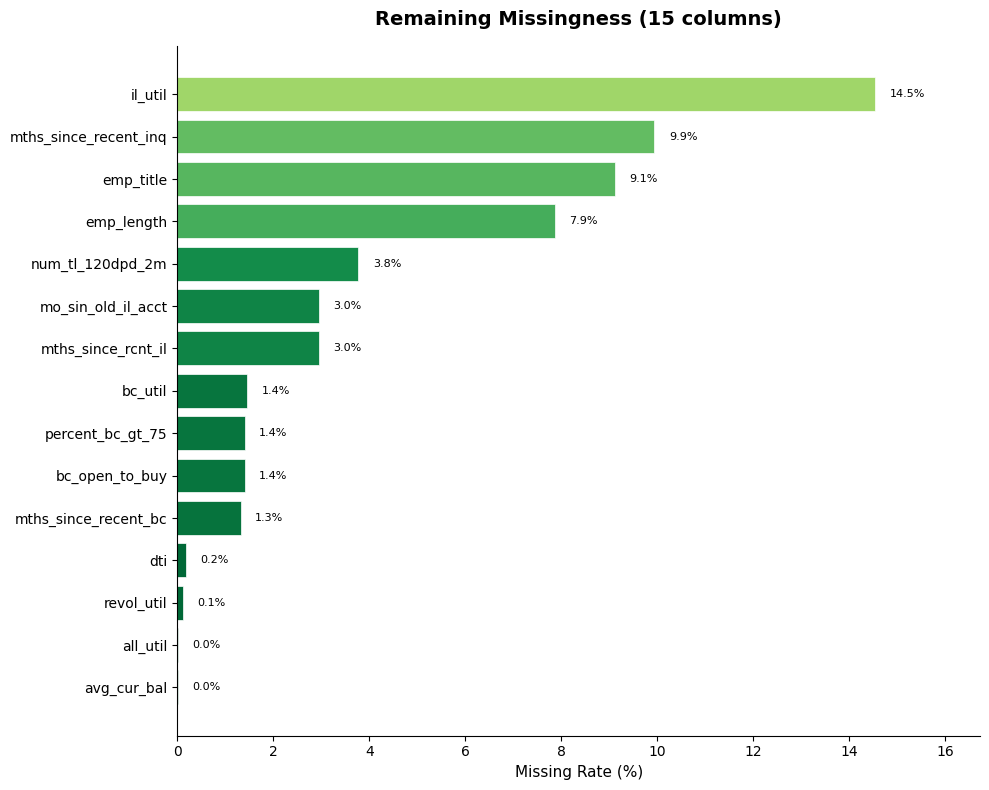

In [18]:
plot_missingness(
    df_clean,
    save_path=EDA_FIGURES_DIR / "05_missingness.png"
)

### Feature Correlation with Target

`int_rate` sits far above all other features in point-biserial correlation with default — a pattern that will recur in the SHAP analysis. The next tier of predictors — `dti`, `revol_util`, `inq_last_6mths` — confirms that leverage and recent credit-seeking behavior are the key risk signals in this dataset beyond the rate itself.

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/figures/06_feature_target_correlation.png


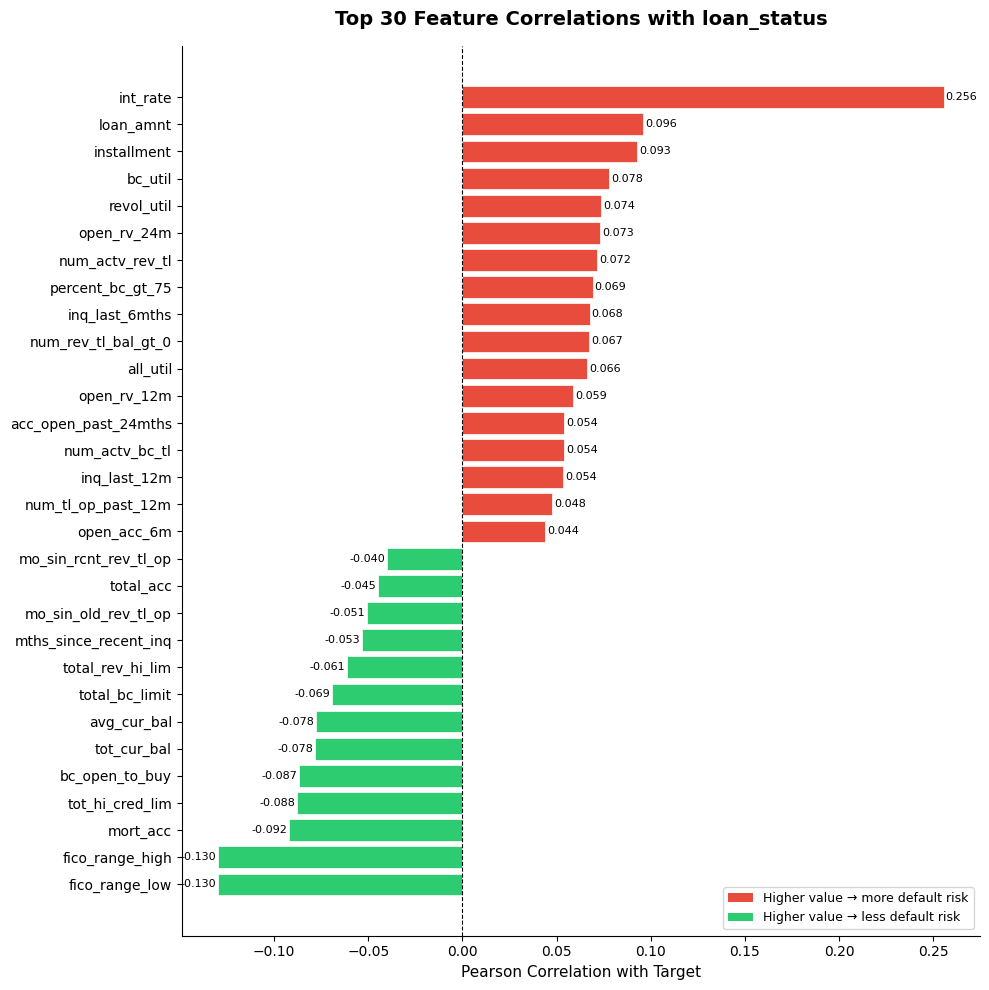

In [19]:
plot_feature_target_correlation(
    df_clean,
    target_col="loan_status",
    top_n=30,
    save_path=EDA_FIGURES_DIR / "06_feature_target_correlation.png"
)

Missing comment about FICO?
On the risk-increasing side (red): `int_rate` at 0.258 is by far the strongest predictor — which makes sense since Lending Club's own rate assignment was risk-based, so high rates signal high perceived risk. `dti`, `revol_util`, `bc_util`, and `percent_bc_gt_75` all pointing positive confirms that leverage and utilization are default drivers. `inq_last_6mths` being positive is also intuitive — borrowers shopping for credit aggressively are often in financial stress.

On the risk-reducing side (green): `bc_open_to_buy`, `tot_hi_cred_lim`, `avg_cur_bal`, and `mort_acc` being negative makes sense — borrowers with more available credit, higher limits, and mortgage accounts tend to be more creditworthy. `mths_since_recent_inq` being negative is the flip side of inquiries — longer time since last inquiry means less recent credit stress.

---

## Feature Engineering & Selection

Raw features tell an incomplete story. A borrower's debt-to-income ratio means something different at 12% interest versus 24% interest. A high revolving balance looks different against a 30K income versus a 150K income. The engineered features below capture these relationships explicitly rather than leaving the model to infer them.

### Engineer Features

Fourteen new features are added covering affordability ratios, credit utilization stress, derogatory history, credit velocity, rate-adjusted risk, and FICO-based credit quality. The origination FICO score — absent from earlier dataset versions — is available here and forms the basis of two engineered features.

In [20]:
df_clean = engineer_features(df_clean)
print(df_clean.shape)

Created: credit_age_months
Applied: _add_burden_ratios -> added features: ['loan_to_income', 'payment_to_income', 'revol_bal_to_income']
Applied: _add_utilization_composite -> added features: ['utilization_composite']
Applied: _add_derogatory_score -> added features: ['derogatory_score']
Applied: _add_credit_velocity -> added features: ['credit_velocity', 'seasoning_ratio']
Applied: _add_rate_features -> added features: ['rate_to_dti', 'rate_to_income', 'rate_utilization_stress', 'affordability_gap']
Applied: _add_fico_features -> added features: ['fico_dti_risk']
Dropped 4 features: ['emp_title', 'earliest_cr_line', 'grade', 'sub_grade']
Shape after feature engineering: (586951, 92)
(586951, 92)


### Select Core Features


Feature selection lands on 33 core features — a deliberate choice that proves consequential. Expanding to the full 92 features reduces XGBoost AUC by 0.0105, confirming that curated feature selection is meaningful for tree-based models. Notebook 3 shows the opposite pattern holds for neural networks, where broader input improves performance.

In [21]:
df_clean = select_core_features(df_clean)

Selecting 33 core features and the target


### Assess Features

In [22]:
assessment = assess_features(df_clean, "loan_status")

  FEATURE ASSESSMENT REPORT

Total numeric features assessed: 25

Zero variance features (0): None

Low variance features below 0.01 (0):
  None

Highly correlated pairs above 0.85 (2):
  utilization_composite <-> revol_util: 0.9622
  rate_to_dti <-> dti: 0.8838


### Clean Data Summary

In [23]:
save_data_summary_tables(df_clean, "loan_status", EDA_TABLES_DIR / "clean")

Data summary tables saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/clean/missing_values.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/clean/feature_stats.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/clean/target_distribution.csv
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/eda/tables/clean/categorical_counts.csv


### Features and Target

In [24]:
X = df_clean.drop(columns=["loan_status"])
y = df_clean["loan_status"]

### Train / Test Split

In [25]:
X_train, X_test, y_train, y_test = split_data(X, y)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train default rate: {y_train.mean():.3f}")
print(f"y_test default rate:  {y_test.mean():.3f}")

X_train: (469560, 33)
X_test:  (117391, 33)
y_train default rate: 0.216
y_test default rate:  0.216


---

## Baseline Modeling

Three architectures establish the baseline — **logistic regression** as a linear benchmark, **HistGradientBoosting** as sklearn's native tree ensemble, and **XGBoost** as the industry standard for tabular credit data. All three use the same feature set and balanced class weighting. 

The comparison answers a simple question: 
>Does model complexity matter on this feature set?

### Logistic Regression

#### Configuration & Training

In [26]:
# Build model
lr_pipeline = build_pipeline(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    X_train
)

# Fit model
lr_pipeline.fit(X_train, y_train)

# Save artifact
lr_model_path = PARAMS_DIR / "lr_pipeline.joblib"
joblib.dump(lr_pipeline, lr_model_path)

print(f"\n✅ Artifact saved:\n  {lr_model_path}")


✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/params/lr_pipeline.joblib


#### Evaluation

In [27]:
# Evaluate
lr_metrics = evaluate_classifier(
    lr_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

# Save metrics
metrics_path = TABLES_DIR / "lr_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(lr_metrics, f, indent=2)

print(f"\n✅ Artifact saved:\n  {metrics_path}")

  Logistic Regression — Classification Evaluation
  ROC-AUC:           0.7141
  Gini Coefficient:  0.4282
  KS Statistic:      0.3090
  Avg Precision:     0.4006
  Brier Score:       0.2160  (lower is better)
-------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default       0.87      0.66      0.75     91983
     Default       0.34      0.65      0.45     25408

    accuracy                           0.66    117391
   macro avg       0.61      0.65      0.60    117391
weighted avg       0.76      0.66      0.69    117391

Confusion Matrix:
[[60662 31321]
 [ 8938 16470]]

✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/tables/lr_metrics.json


### Gradient Boosting

#### Configuration & Training

In [28]:
# Build pipeline
gb_pipeline = build_pipeline(
    HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    ),
    X_train
)

# Compute weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Fit model
gb_pipeline.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

# Save artifact
gb_model_path = PARAMS_DIR / "gb_pipeline.joblib"
joblib.dump(gb_pipeline, gb_model_path)

print(f"\n✅ Artifact saved:\n  {gb_model_path}")


✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/params/gb_pipeline.joblib


#### Evaluation

In [29]:
# Evaluate
gb_metrics = evaluate_classifier(
    gb_pipeline,
    X_test,
    y_test,
    "Gradient Boosting"
)

# Save metrics
metrics_path = TABLES_DIR / "gb_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(gb_metrics, f, indent=2)

print(f"\n✅ Artifact saved:\n  {metrics_path}")

  Gradient Boosting — Classification Evaluation
  ROC-AUC:           0.7239
  Gini Coefficient:  0.4478
  KS Statistic:      0.3250
  Avg Precision:     0.4189
  Brier Score:       0.2132  (lower is better)
-------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default       0.88      0.63      0.74     91983
     Default       0.34      0.69      0.46     25408

    accuracy                           0.65    117391
   macro avg       0.61      0.66      0.60    117391
weighted avg       0.76      0.65      0.68    117391

Confusion Matrix:
[[58272 33711]
 [ 7844 17564]]

✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/tables/gb_metrics.json


### XGBoost Model

#### Configuration & Training

In [30]:
# Build pipeline
xgb_pipeline = build_pipeline(
    XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        verbosity=0
    ),
    X_train
)

# Compute class-balanced sample weights
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

# Fit model
xgb_pipeline.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

# Save artifact
model_path = PARAMS_DIR / "xgb_pipeline.joblib"
joblib.dump(xgb_pipeline, model_path)

print(f"\n✅ Artifact saved:\n  {model_path}")


✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/params/xgb_pipeline.joblib


#### Evaluation

In [31]:
# Evaluate
xgb_metrics = evaluate_classifier(
    xgb_pipeline,
    X_test,
    y_test,
    "XGBoost"
)

# Save metrics
metrics_path = TABLES_DIR / "xgb_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(xgb_metrics, f, indent=2)

print(f"\n✅ Artifact saved:\n  {metrics_path}")

  XGBoost — Classification Evaluation
  ROC-AUC:           0.7239
  Gini Coefficient:  0.4477
  KS Statistic:      0.3236
  Avg Precision:     0.4192
  Brier Score:       0.2133  (lower is better)
-------------------------------------------------------
              precision    recall  f1-score   support

 Non-Default       0.88      0.63      0.74     91983
     Default       0.34      0.69      0.46     25408

    accuracy                           0.65    117391
   macro avg       0.61      0.66      0.60    117391
weighted avg       0.76      0.65      0.68    117391

Confusion Matrix:
[[58349 33634]
 [ 7917 17491]]

✅ Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/tables/xgb_metrics.json


### Baseline Comparison

In [32]:
summary = compare_classifiers([lr_metrics, gb_metrics, xgb_metrics])
summary.to_csv(TABLES_DIR / "baseline_model_comparison.csv")

print(summary)
print(f"\n Artifact saved:")
print(f"  {TABLES_DIR / 'baseline_model_comparison.csv'}")

                     roc_auc    gini  ks_statistic  avg_precision  brier_score
model                                                                         
Gradient Boosting     0.7239  0.4478        0.3250         0.4189       0.2132
XGBoost               0.7239  0.4477        0.3236         0.4192       0.2133
Logistic Regression   0.7141  0.4282        0.3090         0.4006       0.2160

 Artifact saved:
  /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/tables/baseline_model_comparison.csv


### ROC Curves

Figure saved to /Users/rnitto/work/playground/01_data_science/01_fintech_ml_portfolio/artifacts/classification/models/figures/01_roc_curves.png


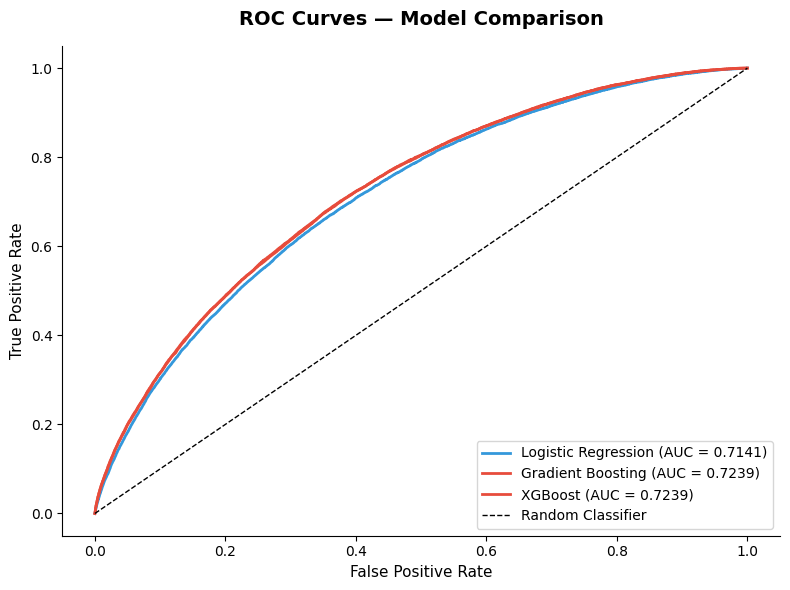

In [33]:
plot_roc_curves(
    models={
        "Logistic Regression": lr_pipeline,
        "Gradient Boosting": gb_pipeline,
        "XGBoost": xgb_pipeline
    },
    X_test=X_test,
    y_test=y_test,
    save_path=FIGURES_DIR / "01_roc_curves.png"
)

---

## Hyperparameter Optimization


Default hyperparameters are a reasonable starting point but rarely optimal. RandomizedSearchCV explores 25 configurations across tree depth, learning rate, subsampling, and regularization parameters. Three-fold cross-validation on the training set ensures the search doesn't overfit to a single data split.

### Search Configuration

In [ ]:
# Hyperparameter search
search = tune_model(
    xgb_pipeline,
    X_train,
    y_train,
    param_grid=get_xgb_param_grid(),
    n_iter=25,
    cv=3
)

# Extract best estimator
best_xgb_pipeline = search.best_estimator_

# Save artifact
model_path = PARAMS_DIR / "best_xgb_pipeline.joblib"
joblib.dump(best_xgb_pipeline, model_path)

print(f"\n✅ Artifact saved:\n  {model_path}")

### Best Parameters

In [ ]:
display_best_params(search.best_params_)

### Evaluation

In [ ]:
# Evaluate tuned model
tuned_xgb_metrics = evaluate_classifier(
    best_xgb_pipeline,
    X_test,
    y_test,
    "XGBoost (Tuned)",
)

# Save metrics
metrics_path = TABLES_DIR / "tuned_xgb_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(tuned_xgb_metrics, f, indent=2)

print(f"\n✅ Artifact saved:\n  {metrics_path}")


The tuner favored deeper trees (max_depth 5), more estimators (600), and meaningful regularization (reg_alpha 0.1, reg_lambda 0.5). The regularization in particular suggests the default model was slightly overfit — the tuned version generalizes better, which shows up in the Brier score improvement as well as AUC.

## Final Model Comparison


Tuning delivered **+0.0123 AUC lift over the untuned baseline** — a meaningful improvement that brings the final model to 0.7362 without any proprietary grade features. The Gini coefficient of 0.4724 approaches the lower bound of what practitioners consider production-quality for consumer credit scoring. The Brier score improvement from 0.2133 to 0.2050 confirms better probability calibration, not just better ranking.

In [ ]:

summary_tuned = compare_classifiers([lr_metrics, gb_metrics, xgb_metrics, tuned_xgb_metrics])
summary_tuned.to_csv(TABLES_DIR / "tuned_model_comparison.csv")

print(summary_tuned)
print(f"\n Artifact saved:")
print(f"  {TABLES_DIR / 'tuned_model_comparison.csv'}")

## Model Explainability


AUC tells you how well the model discriminates. SHAP explains why. The analysis below runs on the tuned XGBoost — understanding what the final model learned is as important as knowing how well it performs.

### SHAP Summary Plot


`int_rate` dominates feature importance — expected given its role as a proxy for borrower risk in the absence of `grade` and `sub_grade`. The more interesting story is in the second tier: `fico_score`, `rate_to_dti`, `payment_to_income`, and `derogatory_score` all contributing meaningfully. These are the engineered features doing the work that `grade` and `sub_grade` used to do.

In [ ]:
shap_values, X_sample, feature_names = get_shap_values(best_xgb_pipeline, X_test)

plot_shap_summary(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "02_shap_summary.png"
)

### SHAP Beeswarm Plot


The beeswarm confirms the direction of each feature's impact. High `int_rate` pushes strongly toward default. High `fico_score` pushes toward non-default. The `rate_to_dti` interaction captures a compounding risk pattern — borrowers paying high rates on already-stressed debt loads are significantly more likely to default than either signal alone would suggest.

In [ ]:
plot_shap_beeswarm(
    shap_values, X_sample, feature_names,
    save_path=FIGURES_DIR / "03_shap_beeswarm.png"
)

## Conclusion


Starting from a raw dataset of 2.9M loans, this notebook built a production-quality credit default classifier using only borrower fundamentals — no proprietary Lending Club grades.

**The headline finding:** 
>Removing `grade` and `sub_grade` costs less than 0.001 AUC. A model built from raw application data, origination FICO scores, and thoughtfully engineered affordability features matches the performance of one that relies on Lending Club's internal risk scoring. That's the result that makes this analytically interesting.

**What drove performance:**
- Origination FICO scores — the single most impactful addition
- `rate_to_dti` — capturing the interaction between pricing and debt burden
- `payment_to_income` — monthly cash flow stress relative to income
- `derogatory_score` — consolidating sparse delinquency signals

**A finding that emerges from the trilogy:** 
>XGBoost performance is sensitive to feature selection in a way that neural networks are not. The 33-feature set here outperforms the full 92-feature set by 0.0105 AUC — deliberate feature selection is a meaningful modeling decision for tree-based architectures, not just a data cleaning step. Notebook 3 shows the opposite pattern holds for neural networks, where broader input actually improves performance.

**Limitations:**
- No hyperparameter search on Gradient Boosting — XGBoost was selected based on baseline parity and wider tuning surface
- Threshold optimization not explored — the 0.5 default threshold is rarely optimal for imbalanced credit data
- Single vintage (2017–2019) — performance on other time periods not validated

**What's next:**
>Notebook 2 uses the same pipeline to predict interest rates — the risk-based pricing problem. If this notebook answered "will this borrower default?", Notebook 2 asks "what rate should they pay?" Notebook 3 then revisits the classification problem with a neural network, testing whether a deeper architecture can find nonlinear signal that XGBoost missed — and whether a broader feature set changes the answer.

---
